<h2>Installing Libraries</h2>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib

Defaulting to user installation because normal site-packages is not writeable


<h2>Importing Libraries</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

<h2>Loading Dataset</h2>

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

<h2>Let's look at first 5 Rows</h2>

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<h2>Info of data</h2>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<h2>Let's check missing values</h2>

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<h2>Removing Unnecessary col</h2>

In [7]:
df=df.drop("customerID", axis=1)

<h2>Manual Encoding(Convert Churn Column into Numeric)</h2>

In [8]:
df["Churn"]=df["Churn"].map({"Yes":1, "No":0})

<h2>Handling TotalCharges Column</h2>

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [10]:
print(df["TotalCharges"]) # total charges was having object we replaced it with the median of total charge

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64


<h2>Encode Categorical Columns</h2>

In [11]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [12]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


<h2>EDA (Exploratory Data Analysis)</h2>

<h2>Correlation Heatmap</h2>

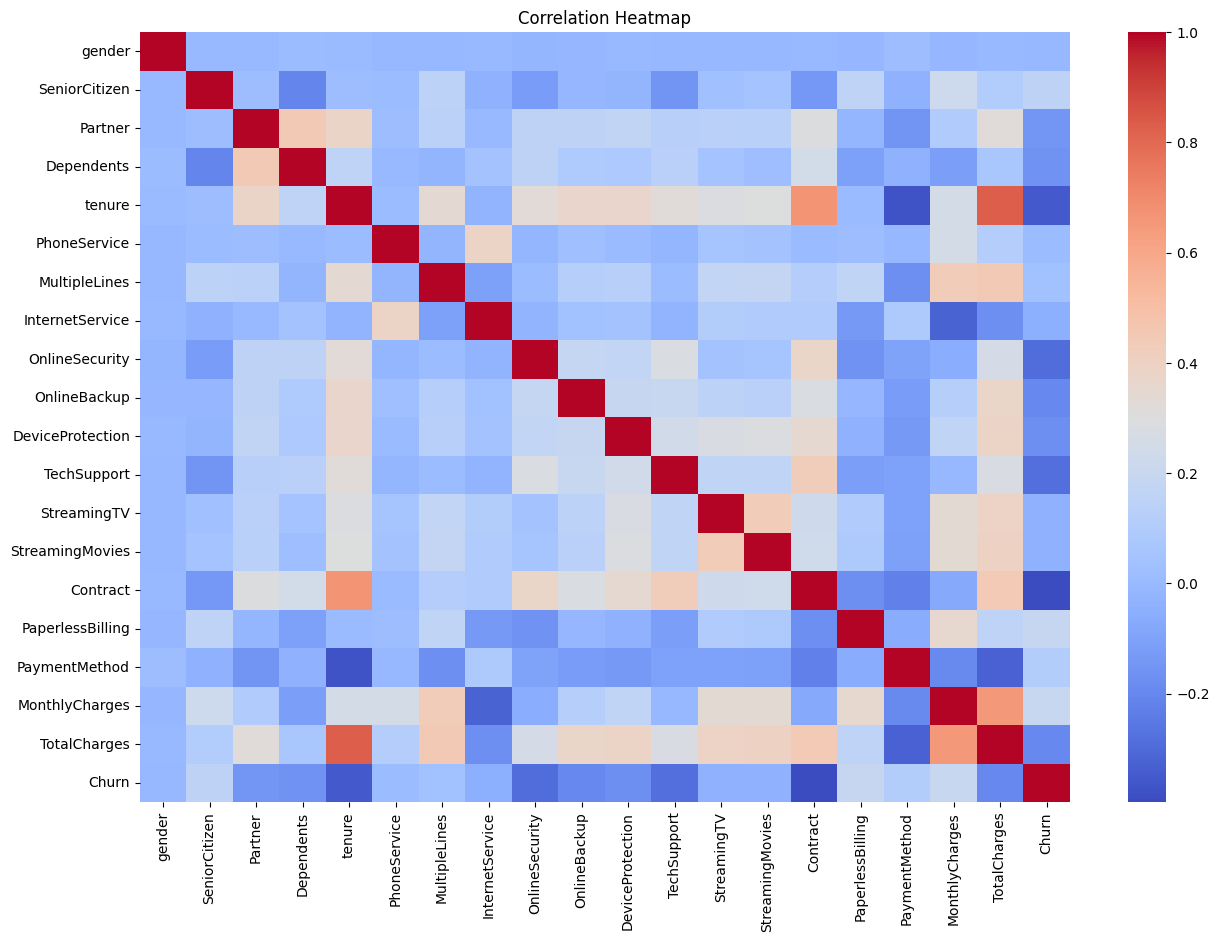

In [13]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

<h2>Churn Distribution</h2>

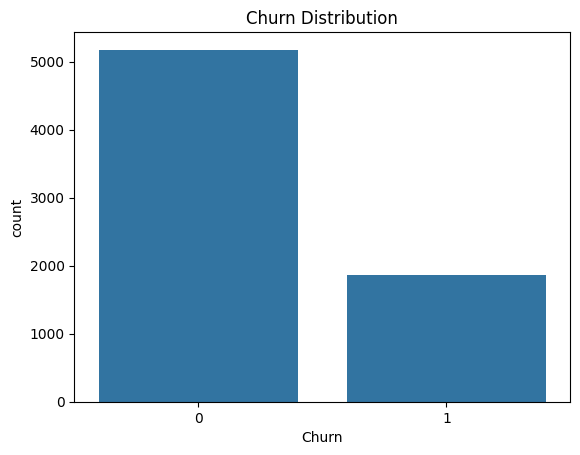

In [14]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

<h2>Monthly Charges vs Churn</h2>

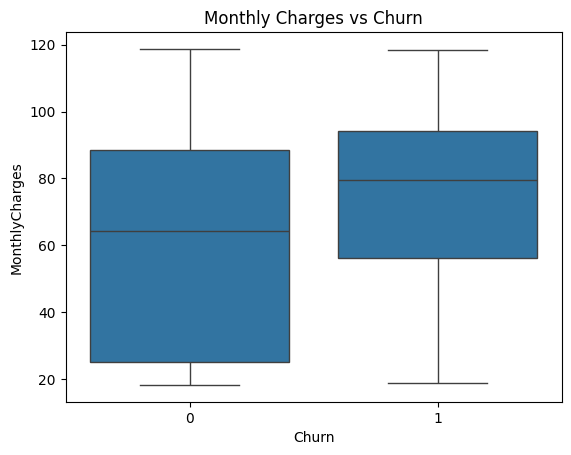

In [15]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

<h2>Features/ Input/ (X) and Target/ Output/ (y)</h2>

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [17]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [18]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

<h2>Train Test Split</h2>

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<h2>Using Logistic Regression Model</h2>

In [20]:
model = LogisticRegression(max_iter=2000)
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


<h2>Train Predictive Model</h2>

In [21]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


<h2>Model Make Predictions</h2>

In [22]:
y_pred = model.predict(X_test)

In [23]:
comparison = pd.DataFrame({
    "Actual Output": y_test,
    "Predicted Output": y_pred
})

comparison.head(20)

,Actual Output,Predicted Output
185,1,1
2715,0,0
3825,0,0
1807,1,1
132,0,0
1263,1,0
3732,0,0
1672,0,0
811,1,0
2526,1,0


<h2>Accuracy</h2>
0≤Accuracy≤1
OR 0%≤Accuracy≤100%

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:",accuracy)
print("Model Accuracy: {:.2f}%".format(accuracy * 100))

Model Accuracy: 0.8168914123491838
Model Accuracy: 81.69%


So model predicts correctly about 82 out of 100 times

<h2>Confusion Matrix</h2>


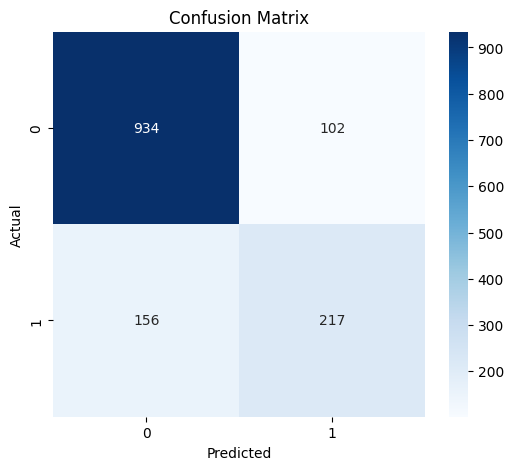

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Confusion Matrix Summary

The confusion matrix represents the performance of the Telecom Customer Churn Prediction model.

| Actual / Predicted | Predicted: No Churn (0) | Predicted: Churn (1) |
|-------------------|-------------------------|----------------------|
| Actual: No Churn (0) | 934 | 102 |
| Actual: Churn (1) | 156 | 217 |

### Interpretation

- **934 customers** were correctly predicted as not churning.
- **217 customers** were correctly predicted as churning.
- **102 customers** were incorrectly predicted as churn when they actually stayed.
- **156 customers** were incorrectly predicted as staying when they actually churned.

### Conclusion

The model performs well in identifying customers who are likely to stay with the telecom company and achieves an overall accuracy of approximately **81.69%**. The confusion matrix indicates that the Logistic Regression model provides good predictive performance for customer churn classification.

<h2>Classification Report</h2>

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



## Classification Report Analysis

The classification report is used to evaluate the performance of the Telecom Customer Churn Prediction model developed using Logistic Regression.

The report measures the model using four important evaluation metrics:

- **Precision** – Measures how many predicted churn customers were actually correct.
- **Recall** – Measures how many actual churn customers were successfully identified by the model.
- **F1-Score** – Harmonic mean of precision and recall, providing a balanced evaluation metric.
- **Support** – Represents the total number of actual instances for each class.

### Model Performance Interpretation

| Class | Precision | Recall | F1-Score |
|-------|------------|---------|----------|
| 0 (No Churn) | 0.86 | 0.90 | 0.88 |
| 1 (Churn) | 0.68 | 0.58 | 0.63 |

### Observations

- The model performs very well in predicting customers who are not likely to churn.
- The churn prediction class also shows satisfactory performance, although recall is comparatively lower.
- The overall model achieved an accuracy of approximately **82%**, indicating strong predictive capability for telecom customer churn classification.

### Conclusion

The Logistic Regression model demonstrates effective classification performance and can be used to predict customer churn behavior with good accuracy. The classification report confirms that the model is capable of identifying churn patterns within the telecom dataset efficiently.

<h2>Saving the Model</h2>

In [27]:
joblib.dump(model, "churn_model.pkl") 

['churn_model.pkl']

In [ ]:
!streamlit run app.py